# Exponential Distribution

The **Exponential distribution** models the waiting time between events in a Poisson process, or the lifetime of a component with a constant failure rate. Its defining feature is the **memoryless property**: given survival to time t, the remaining lifetime has the same distribution as the original.

| Property | Value |
|---|---|
| **Parameters** | β (scale, β > 0); optional μ (location) |
| **Support** | [μ, +∞) |
| **PDF** | f(x) = (1/β) exp(−(x−μ)/β) |
| **CDF** | F(x) = 1 − exp(−(x−μ)/β) |
| **Mean** | μ + β |
| **Median** | μ + β ln(2) |
| **Mode** | μ (always at the lower bound) |
| **Std Dev** | β |
| **CV** | 1 (always — mean equals std dev) |
| **Skewness** | 2 (always right-skewed) |
| **Hazard** | 1/β = constant |
| **Memoryless** | P(X > s+t \| X > s) = P(X > t) |
| **Estimation** | β̂ = x̄ − μ (MLE) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

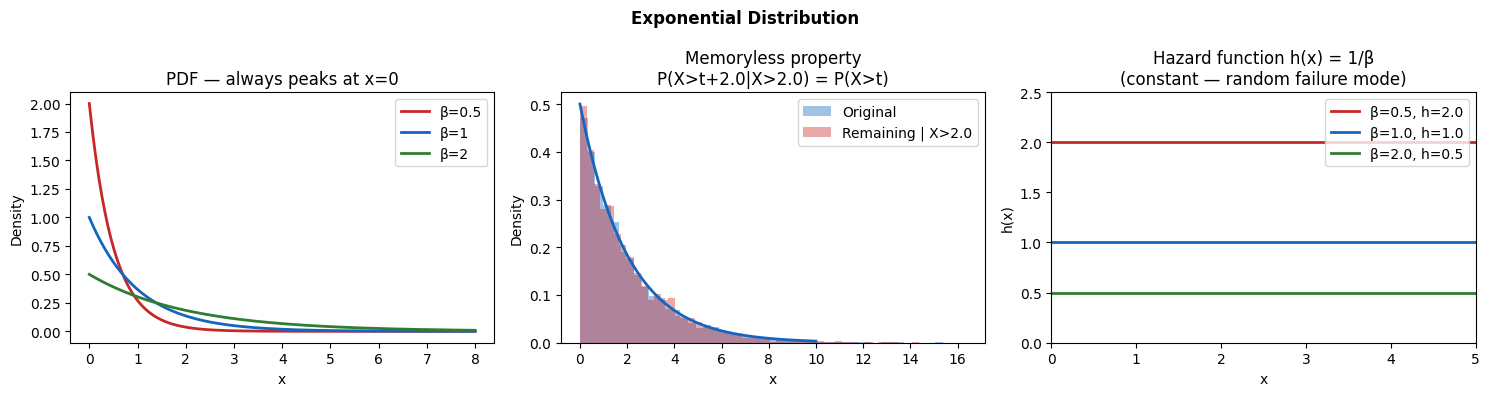

Poisson-Exponential duality:
  Poisson(λ=3): avg 3 events/unit time
  Exponential(β=1/λ=0.333): avg wait 0.333 between events


In [2]:
x = np.linspace(0, 8, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Exponential Distribution', fontsize=12, fontweight='bold')

# PDF
for beta, color, label in [(0.5, '#C62828', 'β=0.5'), (1, '#1565C0', 'β=1'), (2, '#2E7D32', 'β=2')]:
    axes[0].plot(x, stats.expon(scale=beta).pdf(x), color=color, linewidth=2, label=f'β={beta}')
axes[0].set_title('PDF — always peaks at x=0')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend()

# Memoryless property demonstration
np.random.seed(42)
beta = 2.0
data = stats.expon(scale=beta).rvs(10000)
s = 2.0  # conditioning threshold
remaining = data[data > s] - s  # remaining lifetimes given survival past s

x_range = np.linspace(0, 10, 300)
axes[1].hist(data, bins=50, density=True, alpha=0.4, color='#1565C0', label='Original')
axes[1].hist(remaining, bins=50, density=True, alpha=0.4, color='#C62828', label=f'Remaining | X>{s}')
axes[1].plot(x_range, stats.expon(scale=beta).pdf(x_range), color='#1565C0', linewidth=2)
axes[1].set_title(f'Memoryless property\nP(X>t+{s}|X>{s}) = P(X>t)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# Constant hazard function
for beta, color, label in [(0.5, '#C62828', 'β=0.5, h=2.0'),
                             (1,   '#1565C0', 'β=1.0, h=1.0'),
                             (2,   '#2E7D32', 'β=2.0, h=0.5')]:
    h = 1/beta
    axes[2].axhline(h, color=color, linewidth=2, label=label)
axes[2].set_title('Hazard function h(x) = 1/β\n(constant — random failure mode)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('h(x)')
axes[2].set_xlim(0, 5); axes[2].set_ylim(0, 2.5)
axes[2].legend()

plt.tight_layout()
plt.show()

# Poisson-Exponential relationship
print("Poisson-Exponential duality:")
lam = 3  # events per unit time
print(f"  Poisson(λ={lam}): avg {lam} events/unit time")
print(f"  Exponential(β=1/λ={1/lam:.3f}): avg wait {1/lam:.3f} between events")

## Key Takeaways

| | |
|---|---|
| **Memoryless** | The only continuous memoryless distribution — past survival tells you nothing |
| **Constant hazard** | h(x) = 1/β — Weibull shape β=1; models random (not wear-out) failures |
| **CV = 1** | Standard deviation always equals the mean |
| **Poisson link** | Inter-arrival times of a Poisson(λ) process ~ Exponential(β=1/λ) |
| **Estimation** | MLE: β̂ = x̄; use if data is right-skewed with mode at 0 |
| **Use cases** | Component lifetimes (constant failure rate), queue wait times, radioactive decay |